In [2]:
# Channel W1 (Comparison of number of Traces (N) vs the sequence length (n))
# Author: Jaswanthi Mandalapu
# Date: 07 Apr 2026

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

n = 10
# X ~ i.i.d. Bernoulli(1/2)
X = np.random.randint(0, 2, size=n)

print("X =", X)

X = [0 0 1 1 0 0 1 0 0 1]


In [3]:
def channel_W1(x,q=2):
    n = len(x)
    L = np.random.randint(0, n + 1)  # suffix length
    prefix = x[:n - L]
    noise = np.random.randint(0, 2, size=L)
    return np.concatenate([prefix, noise])

In [6]:
def channel_W2(x,q=2):
  n = len(x)

  # pick R ~ Uniform[0, n]
  R = np.random.randint(0, (n + 1)//2)
  L = np.random.randint(0, (n + 1)//2)


  y = x.copy()

  # replace last R bits
  if R > 0:
      y[n - R:] = np.random.randint(0, q, size=R)

  # replace first L bits
  if L > 0:
      y[:L] = np.random.randint(0, q, size=L)

  return y

In [4]:
def channel_W3(x,q=2):
  n = len(x)

  # pick R ~ Uniform[0, n]
  R = np.random.randint(0, n + 1)
  T= np.random.randint(0,n+1)
#   print("R =", R, "T =", T)
  y = x.copy()
  y=y[:n-R]
  # replace last R bits
  if T > 0:
      z=np.random.randint(0, q, size=T)
      y=np.concatenate((y,z))
  

  return y

In [7]:
print(channel_W1(X))
print(channel_W2(X))
print(channel_W3(X))



[0 0 1 1 0 0 1 1 0 0]
[0 0 1 1 0 0 1 1 0 0]
[0 0 1 1 0 0]


In [7]:
def generate_traces(x, N, channel_func=channel_W1,q=2):
  return [channel_func(x, q) for _ in range(N)]

Bitwise Majority Voting Algortihm:

In [8]:
def estimate_x_bitwise(X, N, n, channel_func, trim=True):
    traces=generate_traces(X, N, channel_func)  
    traces = np.array(traces, dtype=object)  # Convert list to array
    
    def trim_and_find_mode(trace):
        if len(trace) >= n:
            return trace[:n]
        else:
            return trace
        
    if trim:
        traces = [trim_and_find_mode(trace) for trace in traces]

    mat = np.zeros((len(traces), n), dtype=np.int8)
    mask = np.zeros_like(mat)

    for i, t in enumerate(traces):
        L = len(t)
        mat[i, :L] = t
        mask[i, :L] = 1

    ones = mat.sum(axis=0)
    counts = mask.sum(axis=0)

    # avoid division, just compare
    return (ones > counts // 2).astype(np.int8)


PFM Algo

In [9]:
def estimate_x_pfm(X,N,n,channel_func,trim=False):
  traces=generate_traces(X, N, channel_func)  
  traces = np.array(traces, dtype=object)  # Convert list to array

  
  if trim:
    traces=list(filter(lambda t: len(t) >= n, traces))  # Keep only traces of length >= n
    traces = [trace[:n] for trace in traces]
  
  # Start with all traces
  subset = list(range(N))
  x_hat = []
  
  # Go through each bit position from left to right
  for i in range(n):
    if len(subset) == 0:
      majority_bit = 0  # Default to 0 if no traces left
    else:
      
      # Only count traces that have index i
      valid_subset = [j for j in subset if i < len(traces[j])]
      
      if len(valid_subset) == 0:
        majority_bit = 0  # Default to 0 if all traces are too short
      else:
        ones = sum(traces[j][i] for j in valid_subset if len(traces[j]) > i)
        # Determine majority bit
        majority_bit = 1 if ones > len(valid_subset) / 2 else 0
        subset = [j for j in valid_subset if traces[j][i] == majority_bit]
      
    x_hat.append(majority_bit)  
      
  return np.array(x_hat)


Estimating Error Probability:

In [10]:
def run_single_trial(X, N, n, channel_func, estimate_func):
    """Run a single trial and return 1 if error, 0 if correct"""
    X_hat = estimate_func(X, N, n, channel_func)
    if not np.array_equal(X, X_hat):
        return 1
    return 0

def estimate_error_prob(n, N, channel_func, estimate_func=estimate_x_bitwise, min_errors=100, max_trials=100000, n_jobs=-1):
  """Estimate error using adaptive trials - keep running until we have min_errors"""
  from scipy import stats
  
  total_errors = 0
  total_trials = 0
  batch_size = 100
  
  # Keep running trials until we have enough errors
  while total_errors < min_errors and total_trials < max_trials:
    # Generate random sequences for this batch
    remaining_trials = min(batch_size, max_trials - total_trials)
    X_trials = [np.random.randint(0, 2, size=n) for _ in range(remaining_trials)]
    
    # Run batch in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(run_single_trial)(X, N, n, channel_func, estimate_func) 
        for X in X_trials
    )
    
    total_errors += sum(results)
    total_trials += remaining_trials
  
  error_prob = total_errors / total_trials
  
  # Compute 95% binomial confidence interval using Wilson score method
  ci = stats.binomtest(total_errors, total_trials, error_prob).proportion_ci(confidence_level=0.95, method='wilson')
  
  return error_prob, ci.low, ci.high

### Calculating min N vs n (delta=0.99)

In [11]:
import csv
import os
import pandas as pd

channels = {
    # 'W1': channel_W1,
    'W2': channel_W2
    # 'W3': channel_W3
}

n_values = range(12,52,2)
csv_file = 'bitwise_large_range_with_ci_bounds.csv'
fieldnames = ['Channel', 'n', 'N_Lower_CI', 'N_Central', 'N_Upper_CI', 'Error_at_N_Central', 'CI_Lower_at_N_Central', 'CI_Upper_at_N_Central']

# Write header if file doesn't exist
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

for channel_name, channel_func in channels.items():
    for n in n_values:
        results_data = []  # Store (N, error, ci_low, ci_high)
        
        # Scale min_errors with n - higher n gets more trials
        min_errors = 30 + (n // 5)  # 30 at n=10, increases by 1 for every 5 units of n
        
        print(f"\nScanning Channel {channel_name}, n={n} (min_errors={min_errors})...")
        
        # Use adaptive step size: start coarse, then fine-grain near threshold
        N = 10
        step = 10
        max_N = 50000
        
        found_threshold = False
        
        while N <= max_N:
            err, ci_low, ci_high = estimate_error_prob(n, N, channel_func, estimate_x_bitwise, min_errors=min_errors)
            results_data.append((N, err, ci_low, ci_high))
            
            # Once error < 0.01, switch to smaller steps to refine
            if err < 0.01 and not found_threshold:
                print(f"  Found threshold region around N={N}, refining...")
                found_threshold = True
                # Go back 2 steps and use smaller step
                N = max(10, N - 2*step)
                step = 10
                results_data = []  # Reset to re-scan with finer resolution
            elif found_threshold and ci_high < 0.01:
                print(f"  N={N}: Error={err:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")
                break
            else:
                N += step
        
        # Find N values at different CI crossings
        N_central = None
        N_lower_ci = None
        N_upper_ci = None
        err_central = None
        ci_low_central = None
        ci_high_central = None
        
        for i, (N, err, ci_low, ci_high) in enumerate(results_data):
            # Find where central estimate crosses 0.01
            if N_central is None and err < 0.01:
                N_central = N
                err_central = err
                ci_low_central = ci_low
                ci_high_central = ci_high
            
            # Find where CI_Upper crosses 0.01 (conservative bound)
            if N_lower_ci is None and ci_high < 0.01:
                N_lower_ci = N
            
            # Find where CI_Lower crosses 0.01 (optimistic bound)
            if N_upper_ci is None and ci_low < 0.01:
                N_upper_ci = N
        
        # Only save if we found the central estimate
        if N_central is not None:
            result = {
                'Channel': channel_name,
                'n': n,
                'N_Lower_CI': N_lower_ci if N_lower_ci is not None else N_central,
                'N_Central': N_central,
                'N_Upper_CI': N_upper_ci if N_upper_ci is not None else N_central,
                'Error_at_N_Central': err_central,
                'CI_Lower_at_N_Central': ci_low_central,
                'CI_Upper_at_N_Central': ci_high_central
            }
            
            with open(csv_file, 'a', newline='') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
                writer.writerow(result)
            
            # Calculate error bars (distance from central to bounds)
            lower_err = N_central - (result['N_Lower_CI'])
            upper_err = (result['N_Upper_CI']) - N_central
            print(f"  --> Channel {channel_name}, n={n}: N={N_central} +{upper_err:.0f}/-{lower_err:.0f}")
        else:
            print(f"  --> No result found for n={n}")

print("\nResults saved to:", csv_file)


Scanning Channel W2, n=20 (min_errors=34)...


KeyboardInterrupt: 

In [ ]:

# Plot N vs n with confidence intervals
df = pd.read_csv(csv_file)

fig, axes = plt.subplots(1, len(df['Channel'].unique()), figsize=(12, 5))
if len(df['Channel'].unique()) == 1:
    axes = [axes]

for idx, (ax, channel_name) in enumerate(zip(axes, df['Channel'].unique())):
    channel_data = df[df['Channel'] == channel_name]
    
    # Calculate error bar sizes
    n_vals = channel_data['n'].values
    N_central = channel_data['N_Central'].values
    N_lower = channel_data['N_Lower_CI'].values
    N_upper = channel_data['N_Upper_CI'].values
    
    # Error bars: distance from central to bounds
    err_lower = N_central - N_lower
    err_upper = N_upper - N_central
    
    # Plot with error bars
    ax.errorbar(n_vals, N_central, yerr=[err_lower, err_upper], 
                fmt='o-', capsize=5, capthick=2, markersize=6, linewidth=2,
                label=f'N (error < 0.01)', color='steelblue')
    
    ax.set_xlabel('Sequence Length (n)', fontsize=12)
    ax.set_ylabel('Number of Traces (N)', fontsize=12)
    ax.set_title(f'Channel {channel_name}: Min N vs Sequence Length\n(95% CI on Error Probability)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('N_vs_n_with_CI.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: N_vs_n_with_CI.png")


### Min N vs Delta (Error Probability Target) with CI Bounds


In [18]:
import csv
import os
import pandas as pd
import numpy as np

channels = {
    'W1': channel_W1,
    'W2': channel_W2
}

n_fixed = 20  # Fixed sequence length
delta_targets = np.linspace(0.01, 0.5, 50)  # Target error probabilities to scan over
csv_file = 'pfm_min_N_vs_delta_with_ci.csv'
fieldnames = ['Channel', 'n', 'Delta_Target', 'N_Lower_CI', 'N_Central', 'N_Upper_CI', 'Error_at_N_Central', 'CI_Lower_at_N_Central', 'CI_Upper_at_N_Central']

# Write header if file doesn't exist
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

for channel_name, channel_func in channels.items():
    for delta_target in delta_targets:
        results_data = []  # Store (N, error, ci_low, ci_high)
        
        min_errors = 30
        
        print(f"\nScanning Channel {channel_name}, n={n_fixed}, delta_target={delta_target:.4f} (min_errors={min_errors})...")
        
        # Use adaptive step size: start coarse, then fine-grain near threshold
        N = 5
        step = 2
        max_N = 10000
        
        found_threshold = False
        
        while N <= max_N:
            err, ci_low, ci_high = estimate_error_prob(n_fixed, N, channel_func, estimate_x_pfm, min_errors=min_errors)
            results_data.append((N, err, ci_low, ci_high))
            
            # Once error < delta_target, switch to smaller steps to refine
            if err < delta_target and not found_threshold:
                print(f"  Found threshold region around N={N}, refining...")
                found_threshold = True
                # Go back 2 steps and use smaller step
                N = max(2, N - 50*step)
                step = 2
                results_data = []  # Reset to re-scan with finer resolution
            elif found_threshold and ci_high < delta_target:
                print(f"  N={N}: Error={err:.6f} (95% CI: [{ci_low:.6f}, {ci_high:.6f}])")
                break
            else:
                N += step
        
        # Find N values at different CI crossings
        N_central = None
        N_lower_ci = None
        N_upper_ci = None
        err_central = None
        ci_low_central = None
        ci_high_central = None
        
        for i, (N, err, ci_low, ci_high) in enumerate(results_data):
            # Find where central estimate crosses delta_target
            if N_central is None and err < delta_target:
                N_central = N
                err_central = err
                ci_low_central = ci_low
                ci_high_central = ci_high
            
            # Find where CI_Upper crosses delta_target (conservative bound)
            if N_lower_ci is None and ci_high < delta_target:
                N_lower_ci = N
            
            # Find where CI_Lower crosses delta_target (optimistic bound)
            if N_upper_ci is None and ci_low < delta_target:
                N_upper_ci = N
        
        # Only save if we found the central estimate
        if N_central is not None:
            result = {
                'Channel': channel_name,
                'n': n_fixed,
                'Delta_Target': delta_target,
                'N_Lower_CI': N_lower_ci if N_lower_ci is not None else N_central,
                'N_Central': N_central,
                'N_Upper_CI': N_upper_ci if N_upper_ci is not None else N_central,
                'Error_at_N_Central': err_central,
                'CI_Lower_at_N_Central': ci_low_central,
                'CI_Upper_at_N_Central': ci_high_central
            }
            
            with open(csv_file, 'a', newline='') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
                writer.writerow(result)
            
            # Calculate error bars (distance from central to bounds)
            lower_err = N_central - (result['N_Lower_CI'])
            upper_err = (result['N_Upper_CI']) - N_central
            print(f"  --> Channel {channel_name}, delta={delta_target:.4f}: N={N_central} +{upper_err:.0f}/-{lower_err:.0f}")
        else:
            print(f"  --> No result found for delta={delta_target:.4f}")

print("\nResults saved to:", csv_file)


Scanning Channel W1, n=20, delta_target=0.0100 (min_errors=30)...
  Found threshold region around N=309, refining...
  N=343: Error=0.006977 (95% CI: [0.004891, 0.009942])
  --> Channel W1, delta=0.0100: N=323 +-38/--20

Scanning Channel W1, n=20, delta_target=0.0200 (min_errors=30)...
  Found threshold region around N=237, refining...
  N=267: Error=0.014091 (95% CI: [0.009945, 0.019931])
  --> Channel W1, delta=0.0200: N=235 +-26/--32

Scanning Channel W1, n=20, delta_target=0.0300 (min_errors=30)...
  Found threshold region around N=201, refining...
  N=229: Error=0.018750 (95% CI: [0.013165, 0.026640])
  --> Channel W1, delta=0.0300: N=197 +-34/--32

Scanning Channel W1, n=20, delta_target=0.0400 (min_errors=30)...
  Found threshold region around N=179, refining...
  N=217: Error=0.028182 (95% CI: [0.019924, 0.039724])
  --> Channel W1, delta=0.0400: N=185 +-36/--32

Scanning Channel W1, n=20, delta_target=0.0500 (min_errors=30)...
  Found threshold region around N=149, refining..

C:\Users\shand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Found threshold region around N=771, refining...
  N=885: Error=0.006383 (95% CI: [0.004475, 0.009097])
  --> Channel W2, delta=0.0100: N=795 +-120/--90

Scanning Channel W2, n=20, delta_target=0.0200 (min_errors=30)...
  Found threshold region around N=607, refining...
  N=707: Error=0.012917 (95% CI: [0.009115, 0.018276])
  --> Channel W2, delta=0.0200: N=635 +-118/--72

Scanning Channel W2, n=20, delta_target=0.0300 (min_errors=30)...
  Found threshold region around N=547, refining...
  N=629: Error=0.020667 (95% CI: [0.014597, 0.029185])
  --> Channel W2, delta=0.0300: N=567 +-70/--62

Scanning Channel W2, n=20, delta_target=0.0400 (min_errors=30)...
  Found threshold region around N=457, refining...
  N=535: Error=0.028182 (95% CI: [0.019924, 0.039724])
  --> Channel W2, delta=0.0400: N=479 +-94/--56

Scanning Channel W2, n=20, delta_target=0.0500 (min_errors=30)...
  Found threshold region around N=427, refining...
  N=485: Error=0.033333 (95% CI: [0.023447, 0.047186])
  --> Ch

### PFM: Min N vs Delta (Error Probability Target) with CI Bounds


In [ ]:
import csv
import os
import pandas as pd
import numpy as np

channels = {
    'W2': channel_W2
}

n_fixed = 20  # Fixed sequence length
delta_targets = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5])
csv_file = 'pfm_min_N_vs_delta_with_ci.csv'
fieldnames = ['Channel', 'n', 'Delta_Target', 'N_Lower_CI', 'N_Central', 'N_Upper_CI', 'Error_at_N_Central', 'CI_Lower_at_N_Central', 'CI_Upper_at_N_Central']

# Write header if file doesn't exist
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()

for channel_name, channel_func in channels.items():
    for delta_target in delta_targets:
        results_data = []  # Store (N, error, ci_low, ci_high)
        
        min_errors = 30
        
        print(f"\nScanning Channel {channel_name}, n={n_fixed}, delta_target={delta_target:.4f} (min_errors={min_errors})...")
        
        # Use adaptive step size: start coarse, then fine-grain near threshold
        N = 5
        step = 5
        max_N = 10000
        
        found_threshold = False
        
        while N <= max_N:
            err, ci_low, ci_high = estimate_error_prob(n_fixed, N, channel_func, estimate_x_pfm, min_errors=min_errors)
            results_data.append((N, err, ci_low, ci_high))
            
            # Once error < delta_target, switch to smaller steps to refine
            if err < delta_target and not found_threshold:
                print(f"  Found threshold region around N={N}, refining...")
                found_threshold = True
                # Go back 2 steps and use smaller step
                N = max(5, N - 2*step)
                step = 5
                results_data = []  # Reset to re-scan with finer resolution
            elif found_threshold and ci_high < delta_target:
                print(f"  N={N}: Error={err:.6f} (95% CI: [{ci_low:.6f}, {ci_high:.6f}])")
                break
            else:
                N += step
        
        # Find N values at different CI crossings
        N_central = None
        N_lower_ci = None
        N_upper_ci = None
        err_central = None
        ci_low_central = None
        ci_high_central = None
        
        for i, (N, err, ci_low, ci_high) in enumerate(results_data):
            # Find where central estimate crosses delta_target
            if N_central is None and err < delta_target:
                N_central = N
                err_central = err
                ci_low_central = ci_low
                ci_high_central = ci_high
            
            # Find where CI_Upper crosses delta_target (conservative bound)
            if N_lower_ci is None and ci_high < delta_target:
                N_lower_ci = N
            
            # Find where CI_Lower crosses delta_target (optimistic bound)
            if N_upper_ci is None and ci_low < delta_target:
                N_upper_ci = N
        
        # Only save if we found the central estimate
        if N_central is not None:
            result = {
                'Channel': channel_name,
                'n': n_fixed,
                'Delta_Target': delta_target,
                'N_Lower_CI': N_lower_ci if N_lower_ci is not None else N_central,
                'N_Central': N_central,
                'N_Upper_CI': N_upper_ci if N_upper_ci is not None else N_central,
                'Error_at_N_Central': err_central,
                'CI_Lower_at_N_Central': ci_low_central,
                'CI_Upper_at_N_Central': ci_high_central
            }
            
            with open(csv_file, 'a', newline='') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
                writer.writerow(result)
            
            # Calculate error bars (distance from central to bounds)
            lower_err = N_central - (result['N_Lower_CI'])
            upper_err = (result['N_Upper_CI']) - N_central
            print(f"  --> Channel {channel_name}, delta={delta_target:.4f}: N={N_central} +{upper_err:.0f}/-{lower_err:.0f}")
        else:
            print(f"  --> No result found for delta={delta_target:.4f}")

print("\nResults saved to:", csv_file)


ValueError: 'yerr' must not contain negative values

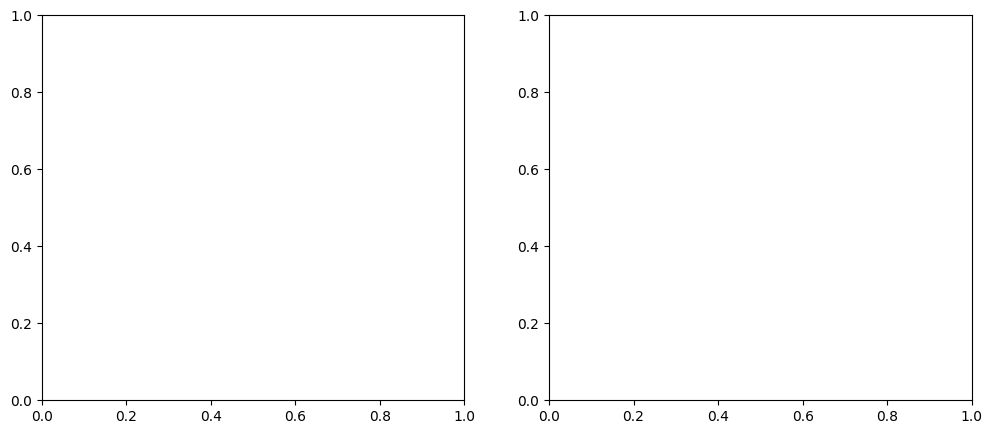

In [10]:
# Plot Min N vs Delta with confidence intervals
import pandas as pd
df_bitwise = pd.read_csv('bitwise_min_N_vs_delta_with_ci.csv')
df_pfm = pd.read_csv('pfm_min_N_vs_delta_with_ci.csv')

fig, axes = plt.subplots(1, len(df_bitwise['Channel'].unique()), figsize=(12, 5))
if len(df_bitwise['Channel'].unique()) == 1:
    axes = [axes]

for idx, (ax, channel_name) in enumerate(zip(axes, df_bitwise['Channel'].unique())):
    # Bitwise data
    channel_data_bw = df_bitwise[df_bitwise['Channel'] == channel_name].sort_values('Delta_Target')
    
    delta_vals_bw = channel_data_bw['Delta_Target'].values
    N_central_bw = channel_data_bw['N_Central'].values
    N_lower_bw = channel_data_bw['N_Lower_CI'].values
    N_upper_bw = channel_data_bw['N_Upper_CI'].values
    
    # Error bars: distance from central to bounds
    err_lower_bw = N_central_bw - N_lower_bw
    err_upper_bw = N_upper_bw - N_central_bw
    
    # Plot bitwise with error bars on log-log scale
    ax.errorbar(delta_vals_bw, N_central_bw, yerr=[err_lower_bw, err_upper_bw], 
                fmt='o-', capsize=5, capthick=2, markersize=6, linewidth=2,
                label=f'Bitwise', color='steelblue')
    
    # PFM data
    channel_data_pfm = df_pfm[df_pfm['Channel'] == channel_name].sort_values('Delta_Target')
    
    delta_vals_pfm = channel_data_pfm['Delta_Target'].values
    N_central_pfm = channel_data_pfm['N_Central'].values
    N_lower_pfm = channel_data_pfm['N_Lower_CI'].values
    N_upper_pfm = channel_data_pfm['N_Upper_CI'].values
    
    # Error bars: distance from central to bounds
    err_lower_pfm = N_central_pfm - N_lower_pfm
    err_upper_pfm = N_upper_pfm - N_central_pfm
    
    # Plot PFM with error bars on log-log scale
    ax.errorbar(delta_vals_pfm, N_central_pfm, yerr=[err_lower_pfm, err_upper_pfm], 
                fmt='s-', capsize=5, capthick=2, markersize=6, linewidth=2,
                label=f'PFM', color='coral')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Target Error Probability (δ)', fontsize=12)
    ax.set_ylabel('Minimum Number of Traces (N)', fontsize=12)
    ax.set_title(f'Channel {channel_name}: Min N vs Error Probability (n={n_fixed})\n(95% CI)', fontsize=12)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend()

plt.tight_layout()
plt.savefig('min_N_vs_delta_with_CI.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: min_N_vs_delta_with_CI.png")
